#Task 3 (50 points):

##Part 1: Implementing Word Embeddings (10 points)
• Use a pre-trained word embedding model (Word2Vec, GloVe, FastText, or BERT
embeddings).

I chose FastText

• Provide a comparative discussion on why you chose this embedding over others.

https://www.geeksforgeeks.org/nlp/pre-trained-word-embedding-in-nlp/

Word2Vec uses two types of architecture, CBOW and Skip-gram. It is really good at understanding "the semantic relation between words".

https://www.geeksforgeeks.org/machine-learning/fasttext-working-and-implementation/

FastText is build upon Word2Vec. It improves upon the capabilities specifically regarding words that aren't in the vocabulary. It uses a subword based strategy to understand things at the character level.

GloVe uses statistics to find the relationship between words. Whwere Word2Vec and FastText by extention focuse on local relationships, GloVe can capture broader ones.

BERT is a contextual model, unlike the prior three. This means that it has a a greater ability to understand complex concepts like words with many meanings.

When it came to the selection process, I eliminated BERT immediately because it was too heavy. I chose FastText over Word2Vec because I know it is an improvement. Finally, knowing the OOV task is ahead, I chose FastText because it already has some built in solutions to that problem.

• Load embeddings efficiently (either from pre-trained vectors or using an NLP library like
Gensim, SpaCy, or Hugging Face).

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.0 MB/s eta 0:00:00


In [2]:
# Download the official Wikipedia FastText model
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.en.zip
!unzip wiki.en.zip

--2026-03-07 23:56:50--  https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.en.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.225.143.109, 13.225.143.122, 13.225.143.99, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.225.143.109|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10356881291 (9.6G) [application/zip]
Saving to: ‘wiki.en.zip’

wiki.en.zip         100%[===================>]   9.65G   202MB/s    in 36s     

2026-03-07 23:57:26 (274 MB/s) - ‘wiki.en.zip’ saved [10356881291/10356881291]

Archive:  wiki.en.zip
  inflating: wiki.en.vec             
  inflating: wiki.en.bin             


In [3]:
import gensim.downloader as api
from gensim.models.fasttext import load_facebook_model
import numpy as np

# https://fasttext.cc/docs/en/english-vectors.html
# https://radimrehurek.com/gensim/downloader.html

# model = api.load('fasttext-wiki-news-subwords-300')
model = load_facebook_model('wiki.en.bin')

In [4]:
print(type(model))

<class 'gensim.models.fasttext.FastText'>


In [5]:
def getWordEmbedding(word):
    word = word.strip()
    try:
        # see if word is in dictionary
        if word in model.wv.key_to_index:
            message = "In Vocab"
        else:
            message = "OOV (Synthesized via Subwords)"
        embedding = model.wv[word]
        return embedding, message
    except Exception as e:
        # error if it cant synthisize anyting
        return np.zeros(300), f"Error: {e}"

• Allow dynamic user input of two words and output their respective embeddings.

• Handle cases where a word is out of vocabulary (OOV) and suggest ways to approximate
its embedding.

In [6]:
print("Enter two words to get their embeddings")
word1 = input("Word 1: ")
word2 = input("Word 2: ")
emb1, message1 = getWordEmbedding(word1)
emb2, message2 = getWordEmbedding(word2)
print(f"Word: {word1}, Message: {message1}, Embedding: {emb1}")
print(f"Word: {word2}, Message: {message2}, Embedding: {emb2}")


Enter two words to get their embeddings
Word 1: hello
Word 2: darling
Word: hello, Message: In Vocab, Embedding: [-1.59445778e-01 -1.82586774e-01  3.34425941e-02  1.88132674e-01
 -6.79033622e-02 -1.36629000e-01 -2.55587995e-01  1.10004298e-01
  1.72745511e-01  5.19705676e-02 -2.33020019e-02  3.88657339e-02
 -2.45147675e-01 -2.15878278e-01  3.59253466e-01 -8.25264454e-02
  1.21755868e-01 -2.67747909e-01  1.00718722e-01 -1.36392534e-01
 -9.26581845e-02  5.18366039e-01  1.77364975e-01  9.48782638e-02
 -1.84613004e-01 -4.28288542e-02  1.41139766e-02  1.68111458e-01
 -1.85646340e-01  3.49757485e-02 -1.02930054e-01  1.79539278e-01
 -5.27656861e-02  7.20466301e-02 -4.27039713e-01 -1.16155647e-01
 -9.48754791e-03  1.41985357e-01 -2.27823898e-01 -1.72918234e-02
  8.28018710e-02 -4.45123851e-01 -7.59354606e-02 -1.43916830e-01
 -8.24606568e-02  2.01227412e-01 -9.53441933e-02 -1.10420734e-01
 -4.68167424e-01  2.03623384e-01 -1.71400771e-01 -4.98496681e-01
  2.89629847e-01 -1.03054538e-01  2.039250

##Part 2: Cosine Similarity Computation (20 points)
• Implement a function that computes the cosine similarity between two-word
embeddings.

In [7]:
def cosineSimilarity(emb1, emb2):
    norm1 = np.linalg.norm(emb1)
    norm2 = np.linalg.norm(emb2)
    dot = np.dot(emb1, emb2)
    return dot / (norm1 * norm2)

In [8]:
print(f"Similarity between {word1} and {word2}: {cosineSimilarity(emb1, emb2)}")

Similarity between hello and darling: 0.34427234530448914


• Explain why cosine similarity is useful in word embedding space.

It is usefull because it helps quantify the reltionships between words. It does this by calculating the cosine of the angle between the two different words. It eliminates the question of magnitude by normalizing to a unit vector.

• Allow batch processing, where users can input multiple word pairs for simultaneous
similarity computation.

In [9]:
wordPairs = []
word1 = 'a'
word2 = 'a'
while word1 != '':
    word1 = input("(leave blank to quit) Word 1: ")
    if word1 == '':
        break
    word2 = input("Word 2: ")
    if word1 != '':
        wordPairs.append((word1, word2))
print('\n\n')
def batchSimilarity(wordPairs):
    similarities = []
    for word1, word2 in wordPairs:
        emb1, message1 = getWordEmbedding(word1)
        print(f"Word: {word1}, Message: {message1}")
        emb2, message2 = getWordEmbedding(word2)
        print(f"Word: {word2}, Message: {message2}")
        result = cosineSimilarity(emb1, emb2)
        print(f"Similarity between {word1} and {word2}: {result}")
        similarities.append(result)
    return similarities

similarities = batchSimilarity(wordPairs)

(leave blank to quit) Word 1: hello
Word 2: my
(leave blank to quit) Word 1: baby
Word 2: hello
(leave blank to quit) Word 1: my
Word 2: darling
(leave blank to quit) Word 1: hello
Word 2: my
(leave blank to quit) Word 1: ragtime
Word 2: gal
(leave blank to quit) Word 1: 



Word: hello, Message: In Vocab
Word: my, Message: In Vocab
Similarity between hello and my: 0.49455392360687256
Word: baby, Message: In Vocab
Word: hello, Message: In Vocab
Similarity between baby and hello: 0.31875285506248474
Word: my, Message: In Vocab
Word: darling, Message: In Vocab
Similarity between my and darling: 0.25461313128471375
Word: hello, Message: In Vocab
Word: my, Message: In Vocab
Similarity between hello and my: 0.49455392360687256
Word: ragtime, Message: In Vocab
Word: gal, Message: In Vocab
Similarity between ragtime and gal: 0.1990426778793335


• Visualization Requirement: Create a 2D or 3D scatter plot (e.g., using PCA or t-SNE) to
visually show how similar and dissimilar words cluster together in the embedding space.

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
def visualizeCluster(wordList):
    vectors = []
    validWords = []
    for word in wordList:
        emb, message = getWordEmbedding(word)
        if "Error" not in message:
            vectors.append(emb)
            validWords.append(word)
    vectors = np.array(vectors)

    pca = PCA(n_components=2)
    reducedVectors = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 10))
    plt.scatter(reducedVectors[:, 0], reducedVectors[:, 1], c='blue', edgecolors='k', alpha=0.7, s=100)

    for i, word in enumerate(validWords):
        plt.annotate(word, (reducedVectors[i, 0], reducedVectors[i, 1]), fontsize=12)

    plt.title('Word Embeddings Visualization')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

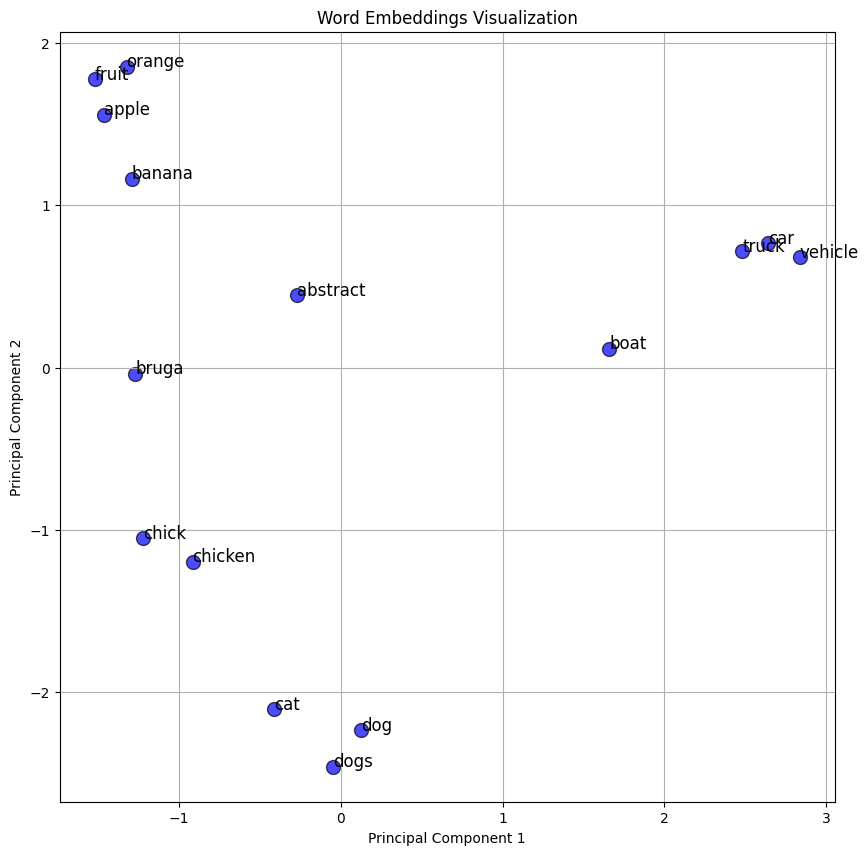

In [11]:
sampleWordList = ['dog', 'dogs', 'cat', 'chicken', 'chick', 'car', 'truck', 'boat', 'vehicle', 'apple', 'banana', 'orange', 'fruit', 'bruga', 'abstract']

visualizeCluster(sampleWordList)

##Part 3: Designing a Novel Dissimilarity Metric (20 points)
• Define a custom dissimilarity score that goes beyond cosine similarity. Possible
approaches include:

o Euclidean distance (How far apart words are in vector space).

o Word entropy-based dissimilarity (How uncommon two words are relative to
each other in corpora).

o Semantic contrast measure (Using external knowledge bases like WordNet).

• Either design your own metric or cite an existing one from literature (provide a proper
reference). Explain why your metric captures novelty/diversity better than cosine
similarity alone.


I am going to use the Euclidean distance. This goes beyond cosine similarity because it also considers magnitude. This is important in the case of models like fast because a magnitude can capture something like frequency. If two words have very similar meanings, but their rate of usage is wildly different, Euclidean distance would capture that difference, whereas cosine might not be able to identify it.

In [12]:
def euclideanDissimilarity(emb1, emb2):
    return np.linalg.norm(emb1 - emb2)

In [13]:
def cosineDissimilarity(emb1, emb2):
    return 1 - cosineSimilarity(emb1, emb2)

In [14]:
def euclideanSimilarity(emb1, emb2):
    return 1 / (1 + euclideanDissimilarity(emb1, emb2))

• Allow users to toggle between different similarity/dissimilarity measures via function
parameters.

In [15]:
def wordDifference(word1, word2, similarityFunction):
    emb1, message1 = getWordEmbedding(word1)
    emb2, message2 = getWordEmbedding(word2)
    result = similarityFunction(emb1, emb2)
    return result

In [16]:
word1 = input("Word 1: ")
word2 = input("Word 2: ")
func = input("Similarity Function (cosineSimilarity, euclideanSimilarity, cosineDissimilarity, euclideanDissimilarity): ")

result = wordDifference(word1, word2, globals()[func])
print(f"Result: {result}")

Word 1: bruga
Word 2: giraffe
Similarity Function (cosineSimilarity, euclideanSimilarity, cosineDissimilarity, euclideanDissimilarity): cosineSimilarity
Result: 0.2305270880460739


• Visualization Requirement:

o Plot the ranking of words based on their similarity/dissimilarity to a given word
(e.g., how words like "cat" rank against "dog," "lion," and "table" using different
metrics).

In [17]:
def plotRanking(targetWord, wordList):
    cosSimilarities = []
    eucSimilarities = []

    for word in wordList:
        emb1, message1 = getWordEmbedding(targetWord)
        emb2, message2 = getWordEmbedding(word)
        if "Error" not in message1 and "Error" not in message2:
            cosSimilarities.append(cosineSimilarity(emb1, emb2))
            eucSimilarities.append(euclideanSimilarity(emb1, emb2))

    sorted = np.argsort(cosSimilarities)[::-1]

    sortedWords = [wordList[i] for i in sorted]
    sortedCos = [cosSimilarities[i] for i in sorted]
    sortedEuc = [eucSimilarities[i] for i in sorted]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(sortedWords, sortedCos, color='b', label='Cosine Similarity')
    ax1.set_ylabel('Cosine Similarity', color='b')
    ax1.tick_params('y', colors='b')

    ax2 = ax1.twinx()
    ax2.plot(sortedWords, sortedEuc, color='r', marker='o', linestyle='-', label='Euclidean Similarity')
    ax2.set_ylabel('Euclidean Similarity', color='r')
    ax2.tick_params('y', colors='r')

    plt.title(f'Ranking of Words for {targetWord}')
    plt.xlabel('Words')
    plt.show()

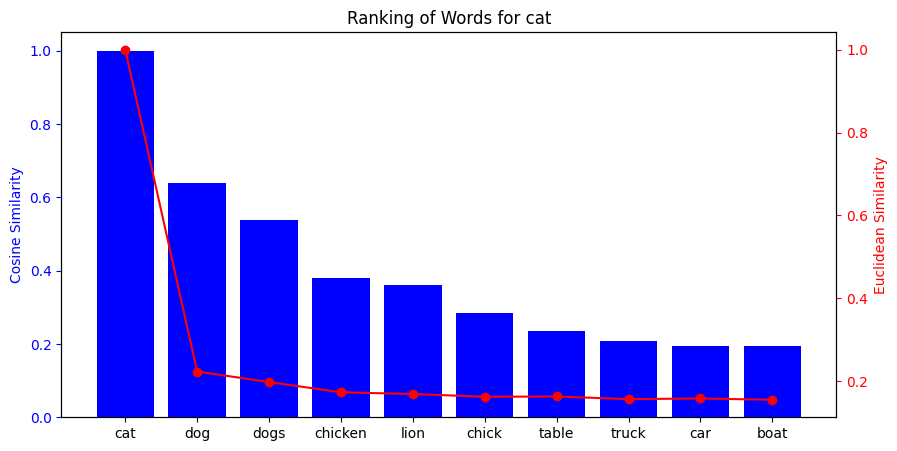

In [18]:
target = 'cat'
wordList = ['dog', 'dogs', 'cat', 'chicken', 'chick', 'car', 'truck', 'boat', 'lion', 'table']

plotRanking(target, wordList)

o Use a heatmap to demonstrate and compare similarity and dissimilarity across
multiple (any number of your choice) word pairs.

In [19]:
import seaborn as sns

def plotHeatmap(wordList, metric):
    matrix = np.zeros((len(wordList), len(wordList)))

    for i in range(len(wordList)):
        for j in range(len(wordList)):
            emb1, message1 = getWordEmbedding(wordList[i])
            emb2, message2 = getWordEmbedding(wordList[j])
            if "Error" not in message1 and "Error" not in message2:
                if metric == 'cosineSimilarity':
                    matrix[i, j] = cosineSimilarity(emb1, emb2)
                elif metric == 'euclideanSimilarity':
                    matrix[i, j] = euclideanSimilarity(emb1, emb2)
                elif metric == 'cosineDissimilarity':
                    matrix[i, j] = cosineDissimilarity(emb1, emb2)
                else:
                    matrix[i, j] = euclideanDissimilarity(emb1, emb2)

    plt.figure(figsize=(8, 8))

    if metric == "cosineSimilarity" or metric == "euclideanSimilarity":
        cmap = "crest"
    else:
        cmap = "YlGnBu_r"

    sns.heatmap(matrix, xticklabels=wordList, yticklabels=wordList, annot=True, fmt=".2f", cmap=cmap)

    if metric == 'cosineSimilarity':
        title = 'Cosine Similarity'
    elif metric == 'euclideanSimilarity':
        title = 'Euclidean Similarity'
    elif metric == 'cosineDissimilarity':
        title = 'Cosine Dissimilarity'
    else:
        title = 'Euclidean Dissimilarity'

    plt.title(title)
    plt.show()

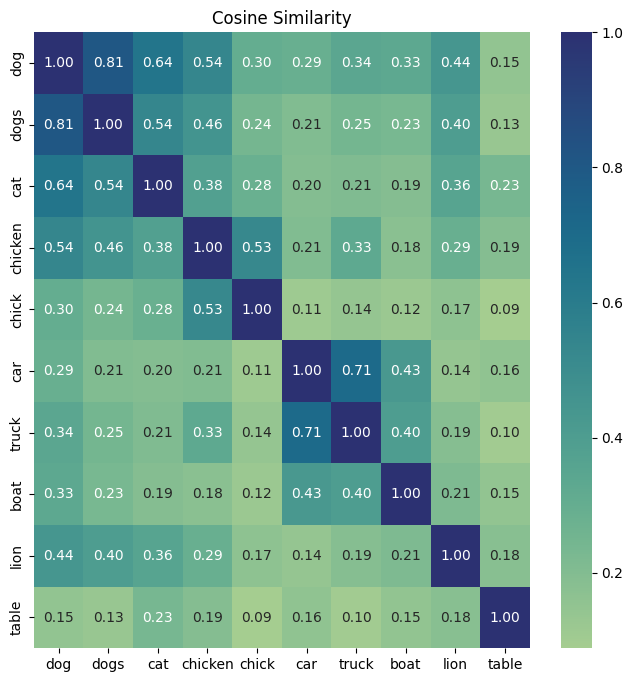

In [20]:
plotHeatmap(wordList, "cosineSimilarity")

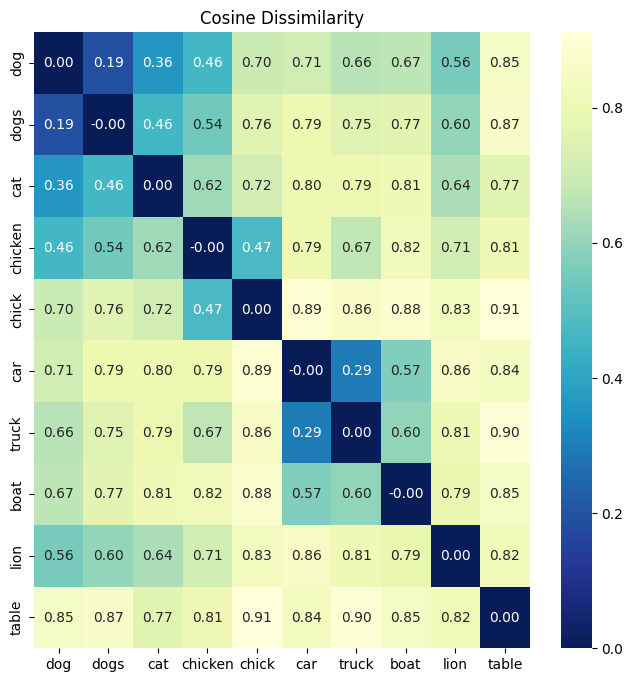

In [21]:
plotHeatmap(wordList, "cosineDissimilarity")